# Sample usage

Evaluates the analytical model of Klassen et al. (2026) on a user-defined grid and
plots the neutron spectral energy fluence in energy and in space.

**Before running**, build the cascade kernel table (~20 min, 306 MB, too large to
ship in the repository):

```
python -m toolbox.diffusion_integrals.precompute_cascade
```

Run this notebook from the repository root.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from toolbox.production_range import BASE
from model import Model

species = 'proton'          # 'proton' or 'carbon'

folder = BASE / f'{species}Solver'
available = sorted(float(f.name.split('_')[1][:-3]) for f in folder.iterdir())
print(f'{len(available)} primary energies available for {species} (MeV/u):')
print(np.array(available))

101 primary energies available for proton (MeV/u):
[ 48.12  54.19  59.82  65.08  70.03  74.72  79.17  83.44  87.53  88.83
  91.48  95.3   99.01 100.07 102.61 106.12 109.56 110.58 112.91 116.2
 119.42 120.45 122.57 125.67 128.72 129.79 131.71 134.65 137.55 138.66
 140.41 143.22 146.01 147.13 148.77 151.5  154.2  155.26 156.89 159.56
 162.21 163.09 164.84 167.46 170.05 170.66 172.62 175.31 177.7  178.01
 181.22 184.81 185.16 188.37 191.87 192.13 195.34 198.76 198.93 202.14
 205.48 205.6  208.79 212.06 212.12 215.3  218.51 218.52 224.81 230.98
 243.03 248.91 254.71 260.43 266.08 271.66 277.19 282.67 288.1  293.5
 298.87 304.21 309.52 314.81 320.07 325.3  330.48 335.92 340.77 347.9
 355.22 362.47 369.64 376.74 383.78 390.75 397.66 404.52 411.32 418.07
 424.77]


## Grids

`E0` must be one of the energies listed above: the depth-energy table of the primary
particle is precomputed per energy in `data/primary_range/`.

In [2]:
E0  = 164.84                       # primary energy, MeV/u
z   = np.linspace(0.5, 45.0, 90)   # depth, cm
rho = np.linspace(0.0, 5.5, 56)    # radius, cm
En  = np.logspace(-13, 0, 250)     # neutron energy, GeV

nz, nr, nE = z.size, rho.size, En.size

## Model

In [3]:
from toolbox.production_range import build_xt_table

params = pd.read_csv(f'fitting_params/params_{species}.csv',
                     index_col=0).loc['opt params'].astype(float)

model = Model(species=species,
              XT=build_xt_table(species, np.array([E0]), En),
              iEp=np.repeat(np.arange(1), nz * nr * nE),
              iEn=np.tile(np.arange(nE), nz * nr))

EP, Z, R, E = [a.ravel() for a in np.meshgrid([E0], z, rho, En, indexing='ij')]

evaluate = (model.spectral_energy_fluence if species == 'proton'
            else model.spectral_energy_fluence_theta)
phi = evaluate((Z, R, E, EP), *params).reshape(nz, nr, nE)

print(params.to_string())
print(f'\nphi{phi.shape}  in cm^-2 per primary, as E_n dPhi/dE_n')

A1              0.028456
gamma1          0.743339
Sigma           0.021767
n_ang           3.086825
d1             -0.317853
a               0.515959
w_c             0.349239
A2              0.001592
gamma2          0.904449
d2             -0.190574
kappa_ev        0.308278
Epk             0.004000
A3              0.000006
gamma3          0.949367
A4            426.906247
gamma4          1.088478
kappa_slow      0.185082
E_th          102.174048
n               2.198053

phi(90, 56, 250)  in cm^-2 per primary, as E_n dPhi/dE_n


## Energy spectrum on the beam axis

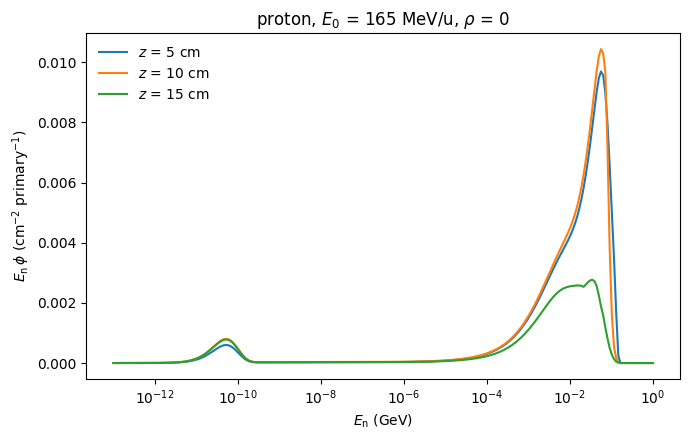

In [4]:
iz = [int(np.abs(z - f).argmin()) for f in (5.0, 10.0, 15.0)]

fig, ax = plt.subplots(figsize=(7, 4.5))
for i in iz:
    ax.plot(En, phi[i, 0, :], label=f'$z$ = {z[i]:.0f} cm')
ax.set_xscale('log')
ax.set_xlabel(r'$E_\mathrm{n}$ (GeV)')
ax.set_ylabel(r'$E_\mathrm{n}\,\phi$ (cm$^{-2}$ primary$^{-1}$)')
ax.set_title(f'{species}, $E_0$ = {E0:.0f} MeV/u, $\\rho$ = 0')
ax.legend(frameon=False)
fig.tight_layout()

## Spatial distribution at selected neutron energies

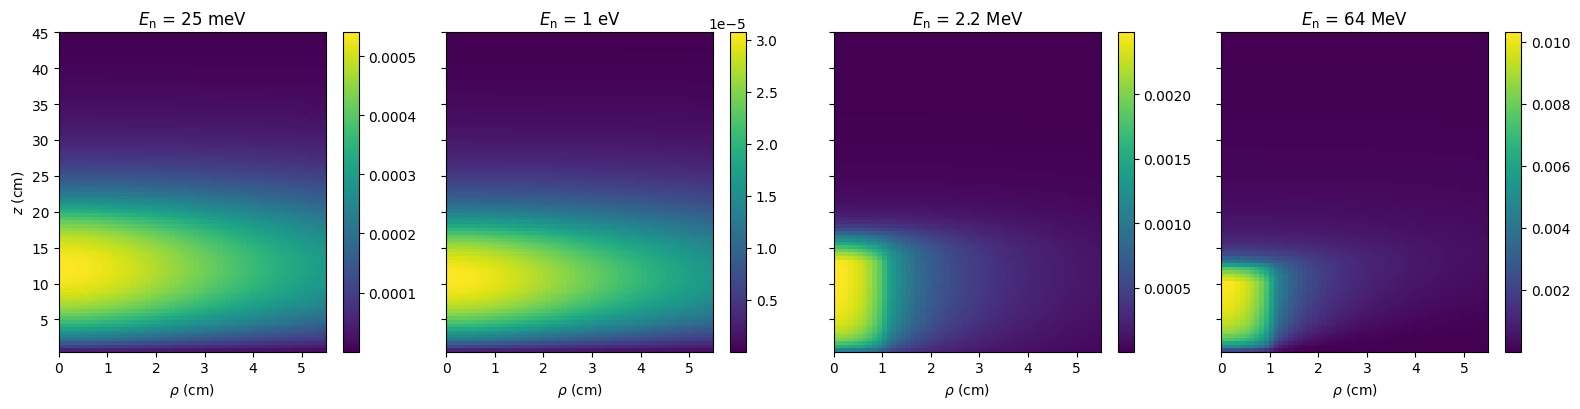

In [5]:
picks = [(2.5e-11, '25 meV'), (1e-9, '1 eV'), (2.2e-3, '2.2 MeV'), (6.4e-2, '64 MeV')]

fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4.2), sharey=True)
for ax, (e, label) in zip(axes, picks):
    k = int(np.abs(En - e).argmin())
    im = ax.imshow(phi[:, :, k], origin='lower', aspect='auto',
                   extent=[rho.min(), rho.max(), z.min(), z.max()])
    ax.set_title(f'$E_\\mathrm{{n}}$ = {label}')
    ax.set_xlabel(r'$\rho$ (cm)')
    fig.colorbar(im, ax=ax)
axes[0].set_ylabel(r'$z$ (cm)')
fig.tight_layout()

## The four regimes separately

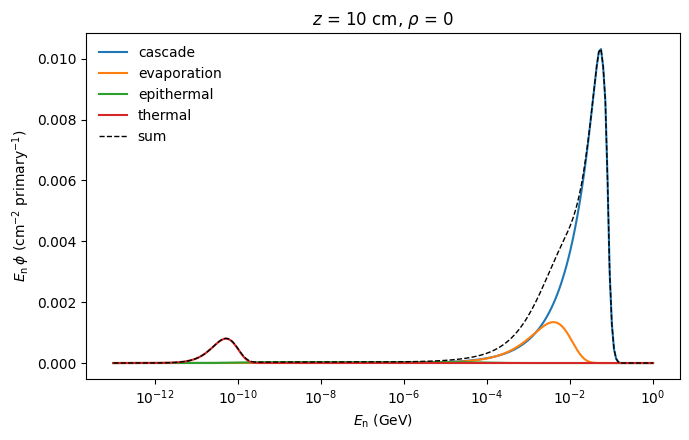

In [6]:
regimes = {
    'cascade':     model.cas(  (Z, R, E, EP), *params[['A1','gamma1','Sigma','n_ang','d1','a','w_c']])
                   if species == 'proton' else
                   model.cas_theta((Z, R, E, EP), *params[['A1','gamma1','Sigma','theta_bar','d1','a','w_c']]),
    'evaporation': model.ev((Z, R, E, EP), *params[['A2','gamma2','d2','kappa_ev','Epk']]),
    'epithermal':  model.ep((Z, R, E, EP), *params[['A3','gamma3','kappa_slow']]),
    'thermal':     model.th((Z, R, E, EP), *params[['A4','gamma4','kappa_slow']]),
}
prefac = model.prefac2(EP, params['E_th'], params['n']).reshape(nz, nr, nE)

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, v in regimes.items():
    ax.plot(En, (prefac * v.reshape(nz, nr, nE))[20, 0, :], label=name)
ax.plot(En, phi[20, 0, :], 'k--', lw=1, label='sum')
ax.set_xscale('log')
ax.set_xlabel(r'$E_\mathrm{n}$ (GeV)')
ax.set_ylabel(r'$E_\mathrm{n}\,\phi$ (cm$^{-2}$ primary$^{-1}$)')
ax.set_title(f'$z$ = {z[20]:.0f} cm, $\\rho$ = 0')
ax.legend(frameon=False)
fig.tight_layout()